# Análise acústica — Bona fide vs Spoof (TTS)

Comparação de características acústicas entre fala real (*bona fide*) e fala
sintética de cinco modelos TTS (F5-TTS, XTTS, ToucanTTS, Fish-Speech, YourTTS).

**Estrutura**
1. Setup (instalação, imports, configuração)
2. Funções auxiliares (tabelas e gráficos reutilizáveis)
3. Carregamento e preparação dos dados
4. F0
5. Jitter, Shimmer e HNR
6. RMS, energia e pausas
7. Cruzamentos centrais (acústica × qualidade)
8. Quadro consolidado
9. Síntese e conclusões
10. Ressalvas metodológicas

# 1. Setup

In [1]:
%%capture
pip install pandas fastparquet matplotlib seaborn scipy librosa tqdm

In [2]:
# Imports (todos centralizados aqui)
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# usados apenas na extração de features de pausa (seção 6)
import librosa
from tqdm.auto import tqdm

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Configuração: caminhos, ordem e nomes dos grupos
PATH_DF     = "./feature_extraction/metrics_brpseechdf.parquet"
PATH_REAPER = "./feature_extraction/metrics_brpseechdf_reaper.parquet"

MODELOS = ["f5tts", "xtts", "toucantts", "fish-speech", "yourtts"]
ORDEM   = ["real"] + MODELOS          # "real" primeiro, depois os modelos

NOMES = {
    "real": "Bona fide", "f5tts": "F5-TTS", "xtts": "XTTS",
    "toucantts": "ToucanTTS", "fish-speech": "Fish-Speech", "yourtts": "YourTTS",
}

### 1.2. Funções auxiliares



In [4]:
# --- parsing e estatísticas ---------------------------------------------------

def to_array(s):
    """Converte série do REAPER (string ou lista) em np.array de floats."""
    if isinstance(s, str):
        s = ast.literal_eval(s)
    return np.asarray(s, dtype=float)

# alias para trechos que ainda chamam parse_list_col
parse_list_col = to_array


def _fmt(g, c):
    """'mediana (média ± desvio)' de uma coluna."""
    return f"{g[c].median():.4g} ({g[c].mean():.4g} ± {g[c].std():.4g})"


def resumo_real_falso(params):
    """Tabela mediana (média ± dp) por métrica, real vs falso."""
    real  = data[data.grupo == "real"]
    falso = data[data.grupo == "falso"]
    return pd.DataFrame({
        "real":  {k: _fmt(real,  v) for k, v in params.items()},
        "falso": {k: _fmt(falso, v) for k, v in params.items()},
    })


def kl_divergence(p_samples, q_samples, n_points=1000):
    """KL(P || Q) via KDE — P=real, Q=modelo."""
    x = np.linspace(min(p_samples.min(), q_samples.min()),
                    max(p_samples.max(), q_samples.max()), n_points)
    p = np.clip(gaussian_kde(p_samples)(x), 1e-10, None)
    q = np.clip(gaussian_kde(q_samples)(x), 1e-10, None)
    p /= p.sum(); q /= q.sum()
    return np.sum(p * np.log(p / q))


def tabela_kl(params):
    """KL(real || modelo) para cada modelo e métrica."""
    real = data[data["modelo_grupo"] == "real"]
    rows = []
    for modelo in MODELOS:
        falso = data[data["modelo_grupo"] == modelo]
        row = {"Model": modelo}
        for titulo, col in params.items():
            p = real[col].dropna().values
            q = falso[col].dropna().values
            row[titulo] = round(kl_divergence(p, q), 4) if len(p) > 1 and len(q) > 1 else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index("Model")


def medianas_por_modelo(params):
    """Mediana de cada métrica por grupo (real + modelos), na ORDEM padrão."""
    med = (data[data["modelo_grupo"].isin(ORDEM)]
           .groupby("modelo_grupo")[list(params.values())]
           .median()
           .reindex(ORDEM))
    med.columns = list(params.keys())
    return med

In [5]:
# --- gráficos -----------------------------------------------------------------

def violin_real_falso(params, suptitle=None, ylabel=""):
    fig, axs = plt.subplots(1, len(params), figsize=(6 * len(params), 4), squeeze=False)
    for ax, (titulo, col) in zip(axs[0], params.items()):
        sns.violinplot(data=data, x="grupo", y=col, inner="box",
                       hue="grupo", legend=False, ax=ax)
        ax.set_title(titulo); ax.set_xlabel(""); ax.set_ylabel(ylabel)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()


def barras_real_falso(params, suptitle=None):
    fig, axs = plt.subplots(1, len(params), figsize=(4.5 * len(params), 4), squeeze=False)
    for ax, (titulo, col) in zip(axs[0], params.items()):
        sns.barplot(data=data, x="grupo", y=col, estimator="median", errorbar=("pi", 50),
                    hue="grupo", legend=False, ax=ax)
        ax.set_title(titulo, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("Mediana")
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()


def hist_real_falso(params, suptitle=None):
    fig, axs = plt.subplots(1, len(params), figsize=(4.5 * len(params), 4), squeeze=False)
    for ax, (titulo, col) in zip(axs[0], params.items()):
        sns.histplot(data=data, x=col, hue="grupo", bins=40, element="step",
                     stat="density", common_norm=False, alpha=0.4, ax=ax)
        ax.set_title(titulo, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("Densidade")
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()


def hist_por_modelo(params, suptitle=None):
    """Grade len(MODELOS) x len(params): real vs cada modelo."""
    real = data[data["modelo_grupo"] == "real"]
    fig, axs = plt.subplots(len(MODELOS), len(params),
                            figsize=(5 * len(params), 4 * len(MODELOS)), squeeze=False)
    for r, modelo in enumerate(MODELOS):
        falso = data[data["modelo_grupo"] == modelo]
        for c, (titulo, col) in enumerate(params.items()):
            ax = axs[r, c]
            ax.hist(real[col].dropna(),  bins=40, alpha=0.5, density=True,
                    label="Real",  color="steelblue")
            ax.hist(falso[col].dropna(), bins=40, alpha=0.5, density=True,
                    label=modelo, color="salmon")
            ax.set_title(f"{titulo} — real vs {modelo}", fontsize=9)
            ax.set_xlabel(""); ax.set_ylabel("Densidade"); ax.legend(fontsize=8)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()


def violin_por_modelo(params, suptitle=None):
    """Um violino por métrica (linhas), grupos no eixo x."""
    fig, axs = plt.subplots(len(params), 1,
                            figsize=(max(8, len(ORDEM) * 1.2), 4 * len(params)), squeeze=False)
    for ax, (titulo, col) in zip(axs[:, 0], params.items()):
        sns.violinplot(data=data, x="modelo_grupo", y=col, order=ORDEM, inner="box",
                       hue="modelo_grupo",
                       palette=["steelblue"] + ["salmon"] * len(MODELOS),
                       legend=False, ax=ax)
        ax.set_title(titulo); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()


def barras_mediana(params, suptitle=None, ylabel="Mediana"):
    """Um subplot de barras por métrica, com a mediana de cada grupo."""
    med = medianas_por_modelo(params)
    fig, axs = plt.subplots(1, len(params), figsize=(4.5 * len(params), 4), squeeze=False)
    for ax, (metrica, color) in zip(axs[0], zip(params.keys(), plt.cm.tab10.colors)):
        ax.bar(np.arange(len(ORDEM)), med[metrica], color=color,
               edgecolor="white", linewidth=0.5, width=0.6)
        ax.set_xticks(np.arange(len(ORDEM)))
        ax.set_xticklabels(ORDEM, rotation=30, ha="right", fontsize=9)
        ax.set_title(metrica, fontsize=11); ax.set_ylabel(ylabel)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

### 1.3. Carregamento e preparação dos dados

In [6]:
# Carrega métricas escalares (df) + séries temporais do REAPER (rea) e junta por 'file'
df  = pd.read_parquet(PATH_DF)
rea = pd.read_parquet(PATH_REAPER)

for col in ["times_reaper", "f0_reaper", "corr"]:
    rea[col] = rea[col].apply(to_array)

data = df.merge(rea[["file", "times_reaper", "f0_reaper", "corr"]],
                on="file", how="inner")

print("escalares:", df.shape, "| séries:", rea.shape, "| juntos:", data.shape)
data.head(2)

escalares: (7891, 17) | séries: (7891, 7) | juntos: (7891, 20)


,file,path,model,patient,f0_mean_hz,f0_std_hz,f0_median_hz,jitter_local_pct,jitter_rap_pct,jitter_ppq5_pct,jitter_ddp_pct,shimmer_local_pct,shimmer_dB,shimmer_apq3_pct,shimmer_apq5_pct,shimmer_dda_pct,hnr_mean_dB,times_reaper,f0_reaper,corr
0,11247_10229_000006-0002.flac,/workspace/BRSpeech-DF/BRSpeech-DF/test/bonafi...,test,bonafide,224.070221,42.466167,224.299072,1.465307,0.513634,0.617712,1.540903,5.273076,0.630496,1.286512,2.331734,3.859535,18.005527,"[0.0, 0.004999999888241291, 0.0099999997764825...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[0.0, 0.27889445424079895, 0.2583264410495758,..."
1,11247_10229_000031-0001.flac,/workspace/BRSpeech-DF/BRSpeech-DF/test/bonafi...,test,bonafide,213.524521,35.721504,214.285721,1.484062,0.520242,0.722275,1.560727,5.217174,0.545237,1.253511,2.296803,3.760533,19.032114,"[0.0, 0.004999999888241291, 0.0099999997764825...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[0.33542969822883606, 0.33542969822883606, 0.5..."


In [7]:
# Colunas derivadas (criadas uma única vez)
data["is_bonafide"] = (data["patient"].str.lower() == "bonafide").astype(int)
data["grupo"]       = np.where(data["is_bonafide"] == 1, "real", "falso")
data["spoof_model"] = data["patient"]

# locutor = 1º token do nome do arquivo
data["speaker"] = data["file"].str.split("_").str[0]

# modelo_grupo: "real" se bonafide, senão o nome do modelo (speaker)
data["modelo_grupo"] = np.where(data["is_bonafide"] == 1, "real", data["speaker"])

print("Classes (patient):")
print(data["patient"].value_counts(), "\n")
print("Splits (model):", data["model"].unique())

# Tabela I do artigo: distribuição por classe
tab1 = (data["patient"].value_counts()
        .rename_axis("spoof_model").reset_index(name="n"))
tab1["%"] = (100 * tab1["n"] / tab1["n"].sum()).round(1)
tab1.loc[len(tab1)] = ["Total", tab1["n"].sum(), 100.0]
display(tab1)

Classes (patient):
patient
spoof       6575
bonafide    1316
Name: count, dtype: int64 

Splits (model): ['test']


,spoof_model,n,%
0,spoof,6575,83.3
1,bonafide,1316,16.7
2,Total,7891,100.0


# Visão geral do experimento

- **Objetivo:** comparar características acústicas de fala real (*bona fide*) contra fala sintética de 5 modelos TTS (F5-TTS, XTTS, ToucanTTS, Fish-Speech, YourTTS), no dataset BRSpeech-DF.
- **Base de dados:** 7.891 áudios após o *merge* das métricas escalares (17 colunas) com as séries temporais do REAPER. Apenas o split `test`.
- **Forte desbalanceamento de classes:** 6.575 *spoof* (83,3%) vs 1.316 *bonafide* (16,7%). Não atrapalha a análise descritiva, mas é crítico caso esses dados alimentem um classificador depois.
- **Métricas acústicas (baixo nível, deste notebook):** F0 (média/desvio), Jitter, Shimmer, HNR e features de pausa (RMS, ZCR, duração, número).
- **Métricas de qualidade do TTS (tabela de referência):** uTMOS (naturalidade percebida), Spk. Sim. (similaridade de locutor), SI-SDR (fidelidade de reconstrução do sinal) e WER (inteligibilidade/erro de ASR). São o contraponto perceptual/linguístico às métricas acústicas — e a análise abaixo cruza os dois mundos.

<center>

| Model | uTMOS ↑ | Spk. Sim. ↑ | SI-SDR (dB) ↑ | WER (%) ↓ |
|---|---|---|---|---|
| F5-TTS | 3,39 | 0,71 | 20,86 | 14,13 |
| XTTS | 3,37 | 0,71 | 25,97 | **5,50** |
| ToucanTTS | 3,20 | 0,60 | **26,50** | 19,18 |
| Fish-Speech | 3,11 | **0,76** | 22,33 | 11,43 |
| YourTTS | 2,58 | 0,41 | 16,92 | 14,21 |
| *Bona fide* | 3,44 | – | – | 9,11 |

</center>

# 2. F0

In [8]:
PARAMS_F0 = {
    "F0 Mean (Hz)": "f0_mean_hz",
    "F0 Std (Hz)":  "f0_std_hz",
}
resumo_real_falso(PARAMS_F0)

,real,falso
F0 Mean (Hz),147.6 (163.1 ± 44.01),152.6 (165.2 ± 40.68)
F0 Std (Hz),34.05 (35.41 ± 12.78),34.13 (36.48 ± 16.62)


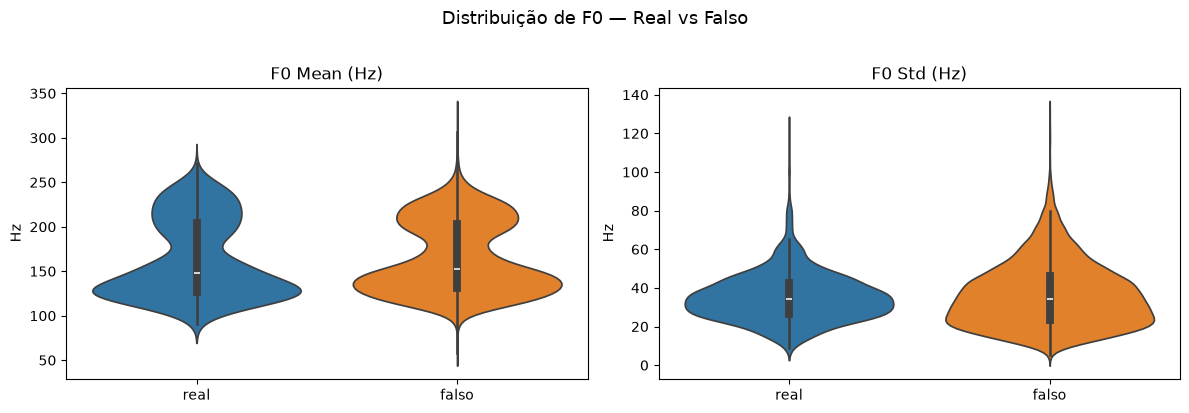

In [9]:
violin_real_falso(PARAMS_F0, suptitle="Distribuição de F0 — Real vs Falso", ylabel="Hz")

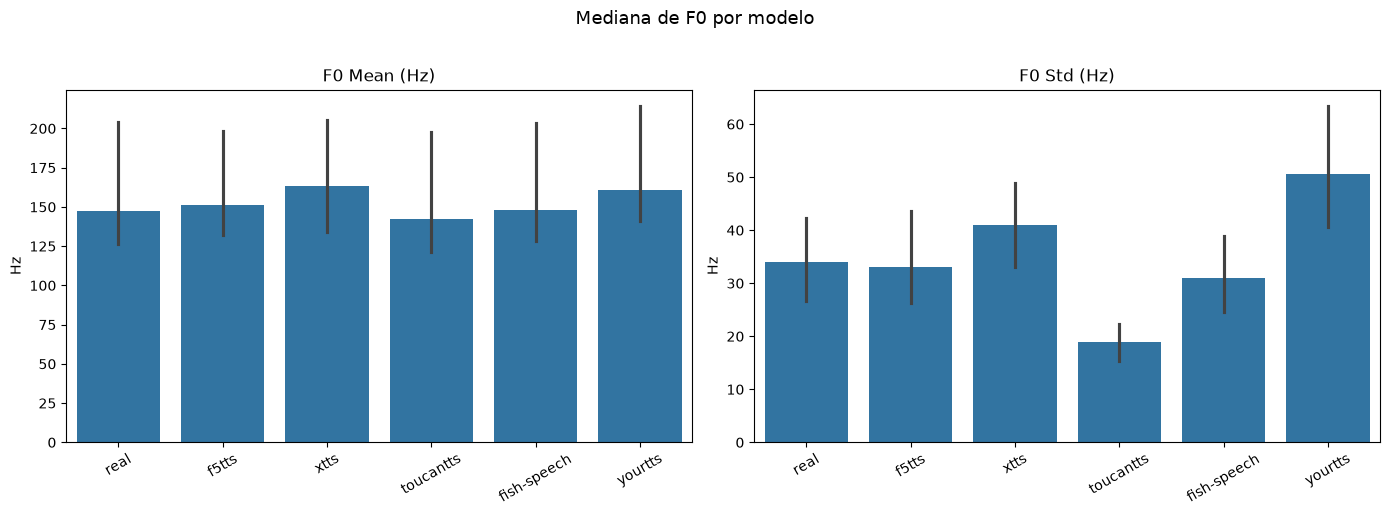

In [10]:
# Mediana de F0 por modelo (com intervalo interpercentil 50%)
fig, axs = plt.subplots(1, len(PARAMS_F0), figsize=(14, 5), squeeze=False)
for ax, (titulo, col) in zip(axs[0], PARAMS_F0.items()):
    sns.barplot(data=data, x="modelo_grupo", y=col, order=ORDEM,
                estimator="median", errorbar=("pi", 50), ax=ax)
    ax.set_title(titulo); ax.set_xlabel(""); ax.set_ylabel("Hz")
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("Mediana de F0 por modelo", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

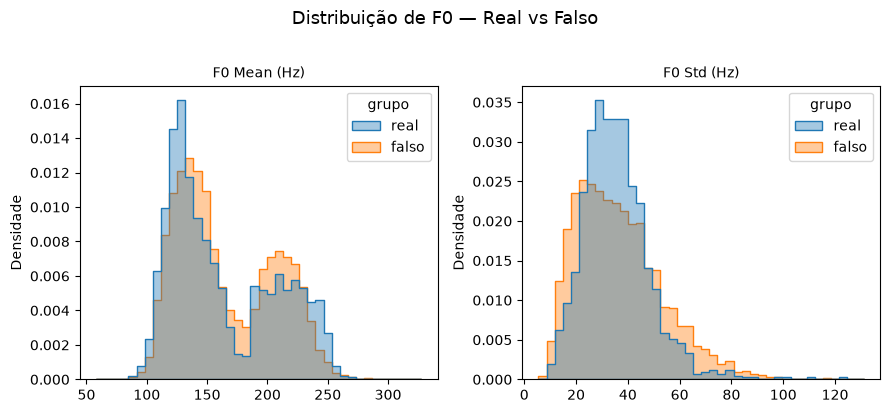

In [11]:
hist_real_falso(PARAMS_F0, suptitle="Distribuição de F0 — Real vs Falso")

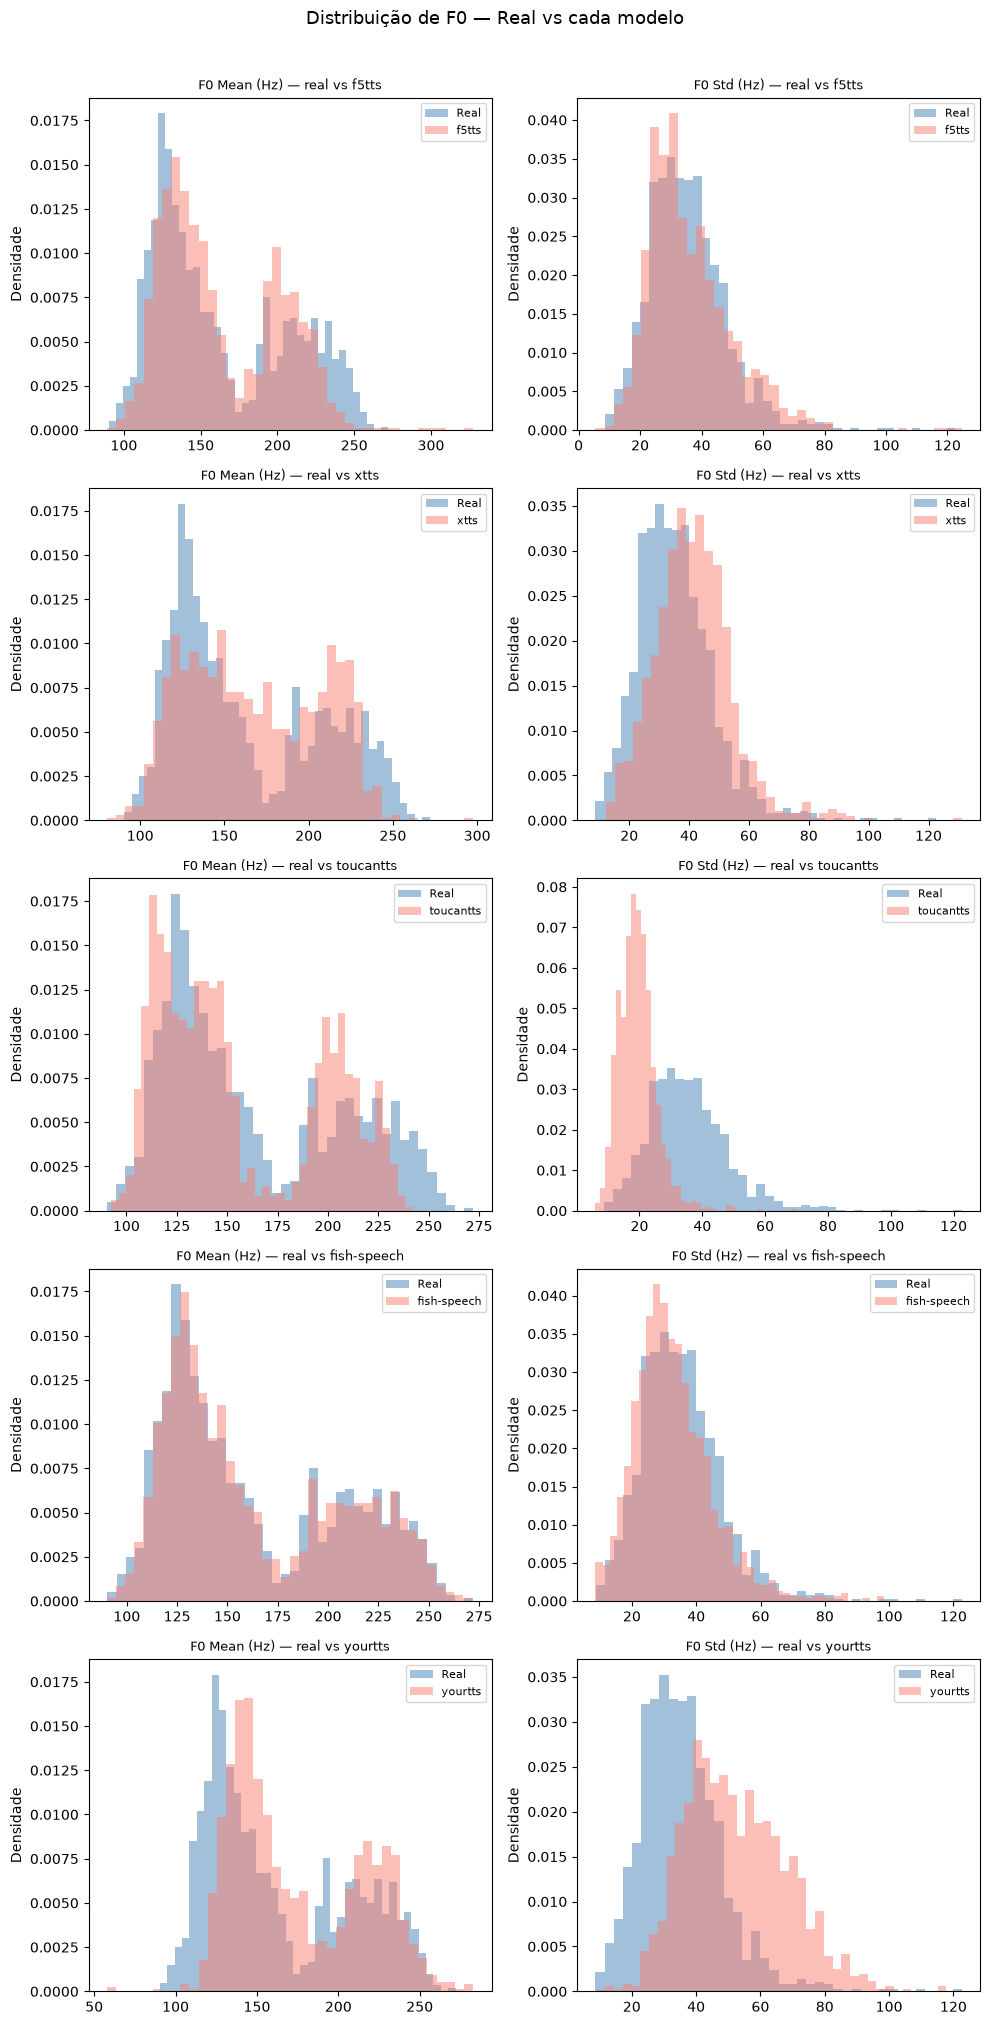

In [12]:
hist_por_modelo(PARAMS_F0, suptitle="Distribuição de F0 — Real vs cada modelo")

In [13]:
tabela_kl(PARAMS_F0)

,F0 Mean (Hz),F0 Std (Hz)
Model,,
f5tts,0.0920,0.0271
xtts,0.0890,0.1451
toucantts,0.1326,1.9461
fish-speech,0.0018,0.0371
yourtts,0.1955,0.7018


### Observações — F0

- **No agregado real vs falso, quase não há diferença:** mediana de F0 média 147,6 Hz (real) vs 152,6 Hz (falso); desvio de F0 praticamente idêntico (34,05 vs 34,13). No atacado, os modelos reproduzem bem a altura tonal.
- **A diferença aparece por modelo (KL):**
  - **Fish-Speech** é o mais fiel na F0 média (KL 0,0018 — virtualmente colado no real) — coerente com sua **maior Spk. Sim. da tabela (0,76)**.
  - **ToucanTTS** tem problema sério de *variabilidade* de F0: KL do desvio = **1,95**, muito acima dos demais. Isso indica prosódia/entonação artificial e **bate com o pior WER da tabela (19,18%)**: entonação instável vira erro de pronúncia para o ASR.
  - **YourTTS** desvia bastante na F0 média (0,196) e no desvio (0,702) — alinhado à **pior Spk. Sim. (0,41)**.
- **Leitura:** a F0 *média* é fácil de imitar; a *dinâmica* da F0 (como varia ao longo da fala) é onde os modelos vazam artefatos — e é o que conecta F0-std ao WER e à similaridade de locutor.

# 3. Jitter, Shimmer e HNR

In [14]:
PARAMS_JSH = {
    "Jitter Local (%)":  "jitter_local_pct",
    "Shimmer Local (%)": "shimmer_local_pct",
    "HNR (dB)":          "hnr_mean_dB",
}
resumo_real_falso(PARAMS_JSH)

,real,falso
Jitter Local (%),2.569 (2.547 ± 0.7768),2.282 (2.296 ± 0.5975)
Shimmer Local (%),8.207 (8.2 ± 2.097),8.652 (8.691 ± 1.656)
HNR (dB),13.49 (14.05 ± 2.808),13.82 (14.11 ± 2.604)


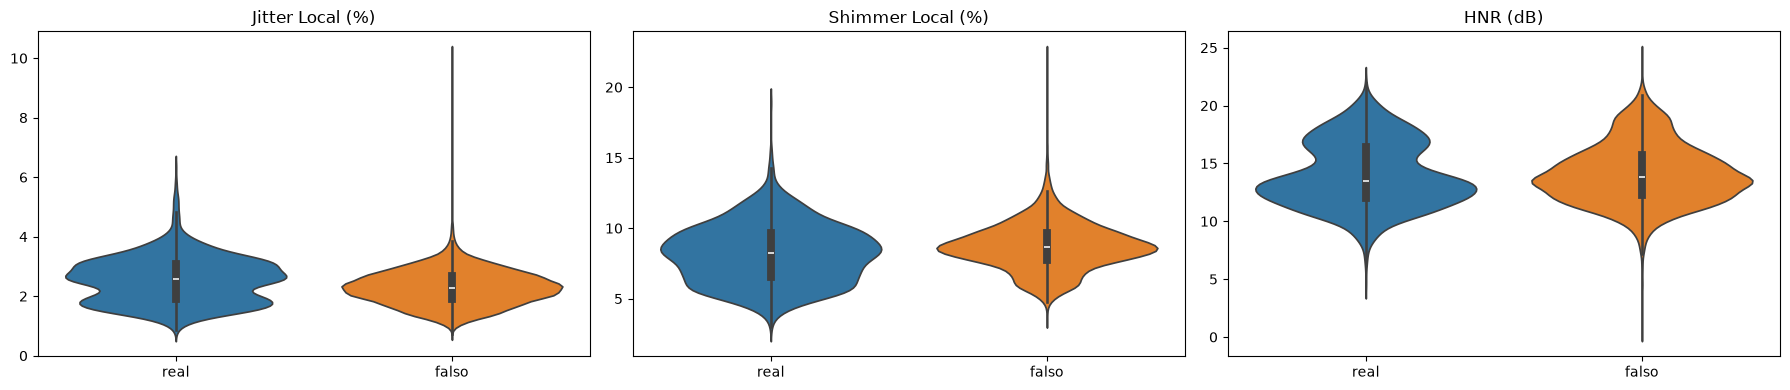

In [15]:
violin_real_falso(PARAMS_JSH)

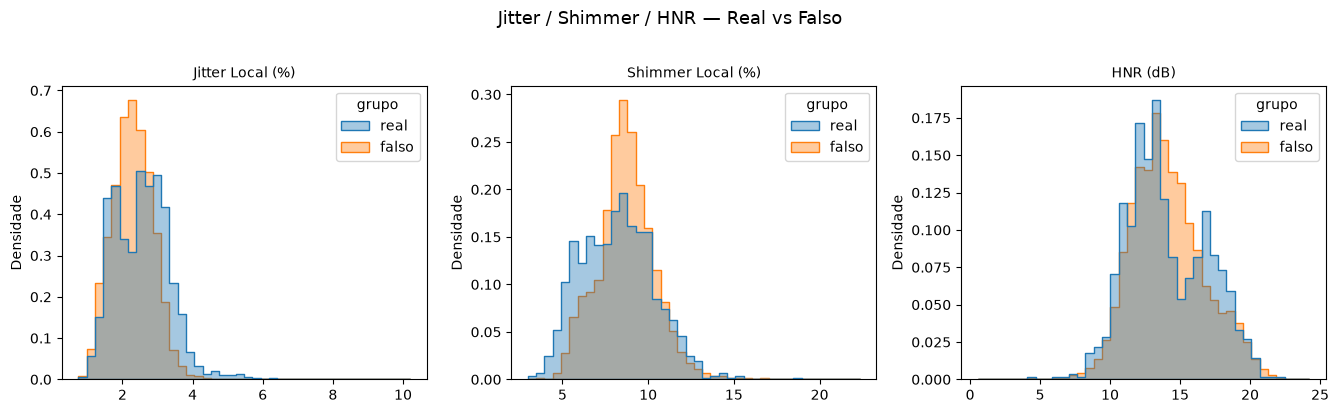

In [16]:
hist_real_falso(PARAMS_JSH, suptitle="Jitter / Shimmer / HNR — Real vs Falso")

### Por modelo

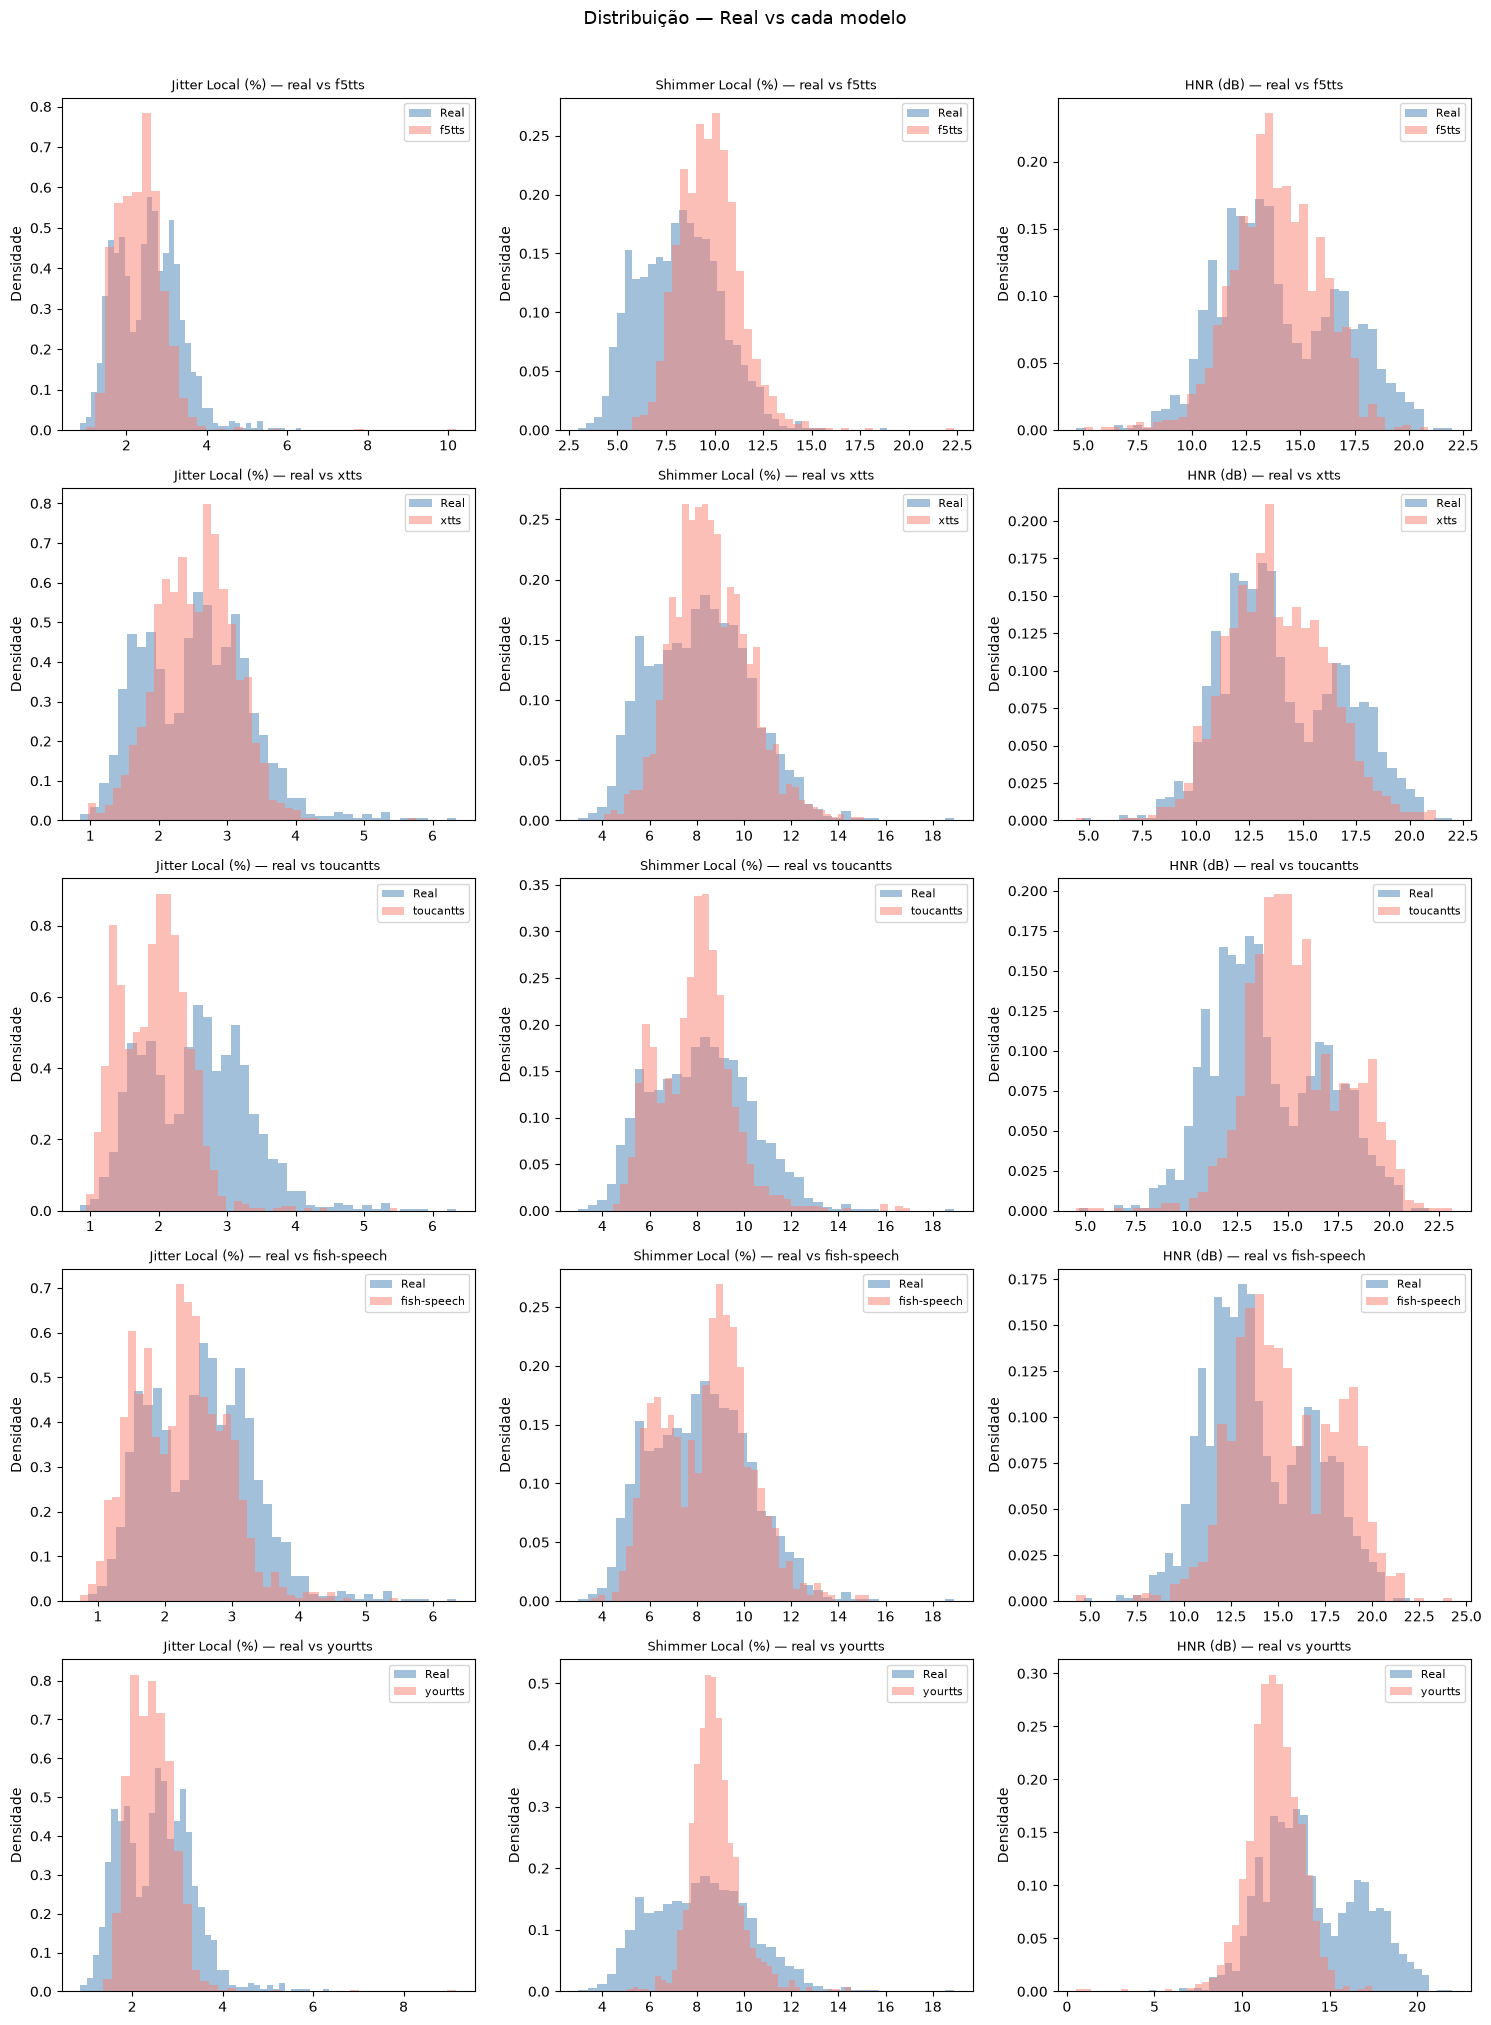

In [17]:
hist_por_modelo(PARAMS_JSH, suptitle="Distribuição — Real vs cada modelo")

In [18]:
tabela_kl(PARAMS_JSH)

,Jitter Local (%),Shimmer Local (%),HNR (dB)
Model,,,
f5tts,0.2421,1.1141,0.2122
xtts,0.2313,0.1694,0.0787
toucantts,0.9254,0.2053,0.3513
fish-speech,0.1542,0.0556,0.1964
yourtts,0.5356,1.0978,1.9854


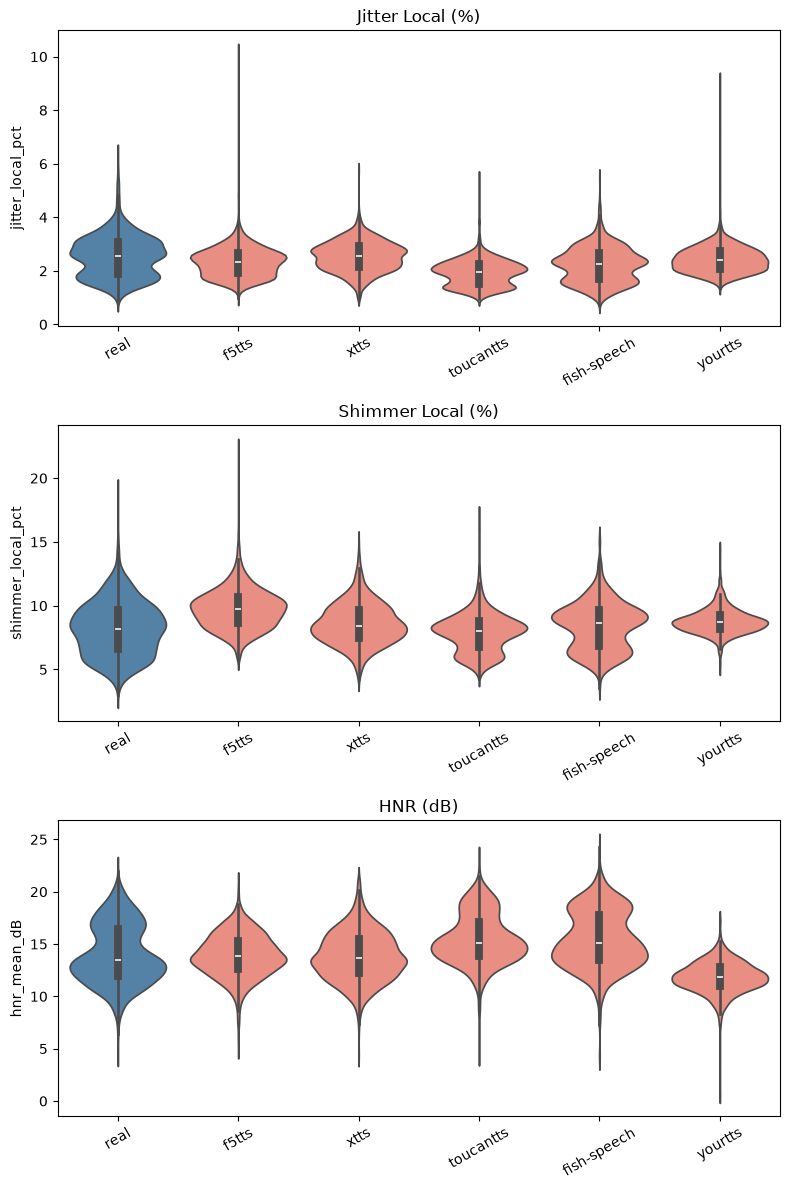

In [19]:
violin_por_modelo(PARAMS_JSH)

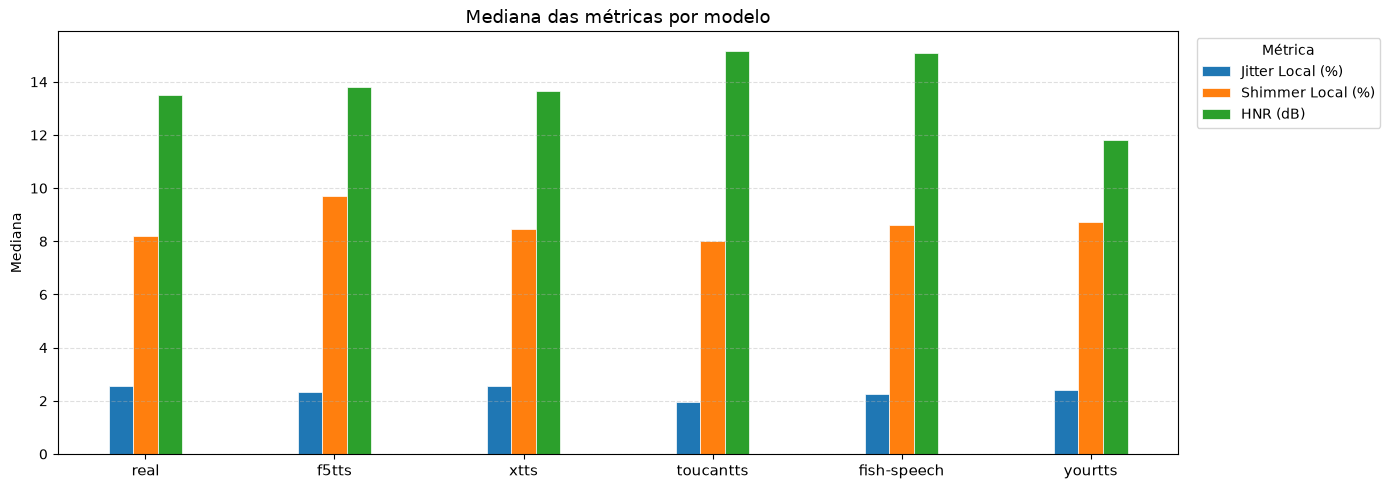

In [20]:
# Mediana das três métricas, agrupadas por modelo (barras lado a lado)
medians = medianas_por_modelo(PARAMS_JSH)

x      = np.arange(len(ORDEM))
width  = 0.13
palette = plt.cm.tab10.colors[:len(PARAMS_JSH)]

fig, ax = plt.subplots(figsize=(14, 5))
for i, (metrica, color) in enumerate(zip(PARAMS_JSH.keys(), palette)):
    offset = (i - len(PARAMS_JSH) / 2 + 0.5) * width
    ax.bar(x + offset, medians[metrica], width=width, label=metrica,
           color=color, edgecolor="white", linewidth=0.5)

ax.set_xticks(x); ax.set_xticklabels(ORDEM, fontsize=11)
ax.set_ylabel("Mediana"); ax.set_title("Mediana das métricas por modelo", fontsize=13)
ax.legend(title="Métrica", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

In [21]:
# Tabela das medianas, com nomes formatados (real por último)
ordem_tab = MODELOS + ["real"]
tab = medians.reindex(ordem_tab).round(3)
tab.index = [NOMES[m] for m in ordem_tab]
tab.index.name = "Model"
tab

,Jitter Local (%),Shimmer Local (%),HNR (dB)
Model,,,
F5-TTS,2.344,9.724,13.823
XTTS,2.567,8.446,13.660
ToucanTTS,1.967,8.021,15.142
Fish-Speech,2.249,8.627,15.082
YourTTS,2.392,8.711,11.828
Bona fide,2.569,8.207,13.490


### Observações — Jitter, Shimmer e HNR

- **Agregado real vs falso sutil:** Jitter real 2,569% vs falso 2,282% (voz real é menos "perfeita"); Shimmer 8,207 vs 8,652; HNR 13,49 vs 13,82 dB.
- **Por modelo (medianas):**
  - **HNR é o grande revelador.** ToucanTTS (15,14 dB) e Fish-Speech (15,08 dB) são **mais "limpos" que o real** — ruído baixo demais. Isso casa com a tabela: **ToucanTTS tem o maior SI-SDR (26,50)** e XTTS o segundo (25,97). Sinal "limpo demais" aparece como HNR alto (acústica) **e** SI-SDR alto (tabela).
  - **YourTTS** tem o menor HNR (11,83 dB) → mais ruidoso, **coerente com pior uTMOS (2,58) e pior SI-SDR (16,92)**.
  - **XTTS** tem jitter (2,567) praticamente idêntico ao bona fide (2,569) — imitação muito boa nesse ponto.
- **Divergências KL:**
  - **Fish-Speech** é o mais próximo do real (menores KLs: 0,154 / 0,056 / 0,196) — confirmado pela **Spk. Sim. de 0,76**.
  - **YourTTS** é o mais distante, sobretudo em **HNR (KL 1,99)** e Shimmer (1,10) — assinatura acústica clara, consistente com seu pior desempenho em toda a tabela.
  - **F5-TTS** tem boa F0/HNR, mas destoa no **Shimmer (KL 1,11)**, apesar do **melhor uTMOS (3,39)**.
  - **ToucanTTS** destoa no **Jitter (0,93)**.

### Jitter (variações)

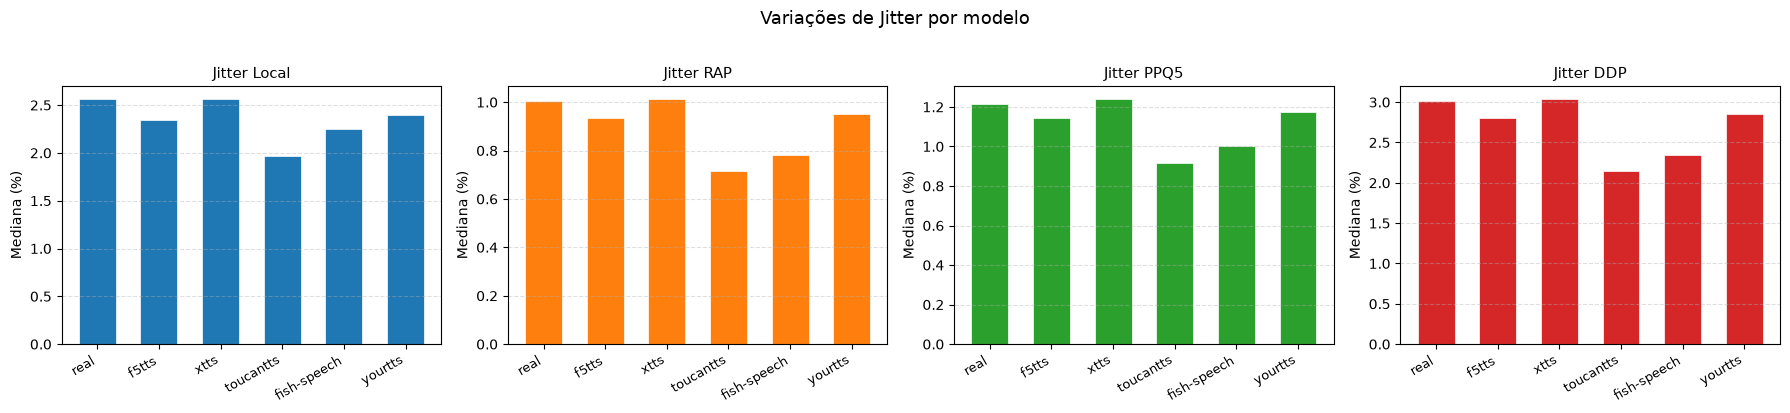

In [22]:
# obs.: removida a chave duplicada "Jitter DDA" (apontava p/ jitter_ddp_pct, igual a DDP)
PARAMS_JITTER = {
    "Jitter Local": "jitter_local_pct",
    "Jitter RAP":   "jitter_rap_pct",
    "Jitter PPQ5":  "jitter_ppq5_pct",
    "Jitter DDP":   "jitter_ddp_pct",
}
barras_mediana(PARAMS_JITTER, suptitle="Variações de Jitter por modelo", ylabel="Mediana (%)")

### Shimmer (variações)

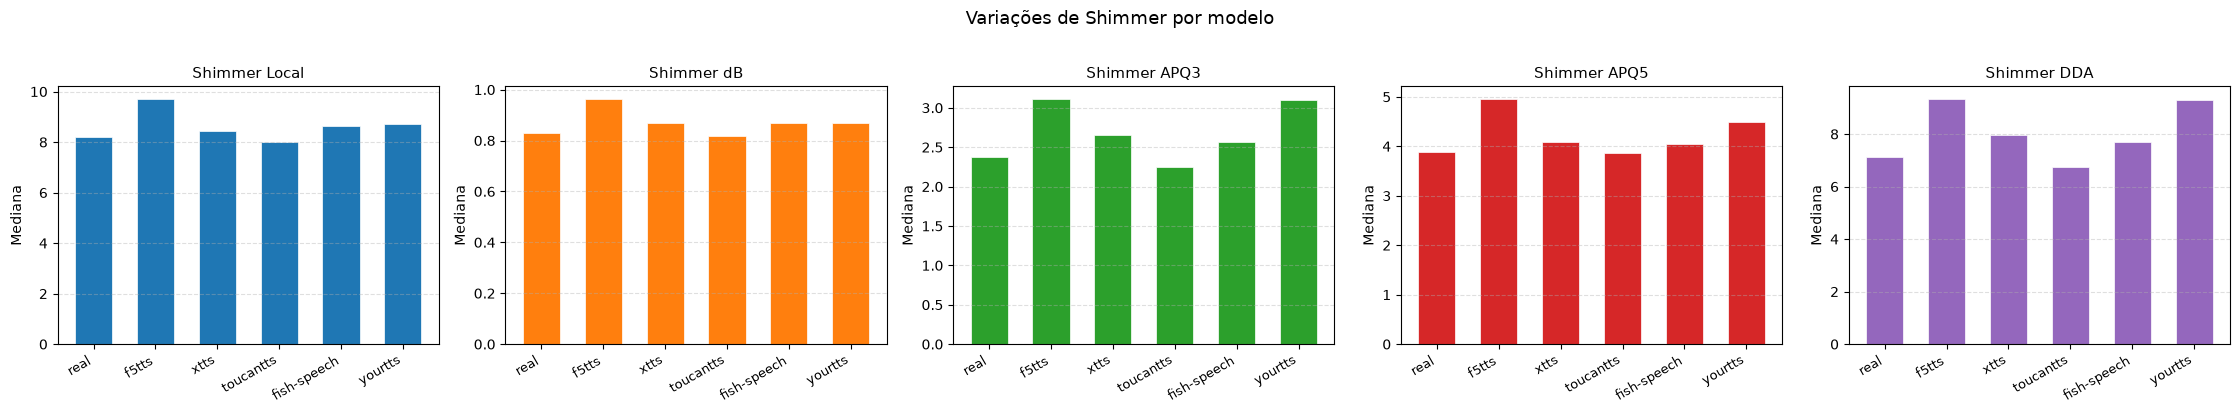

In [23]:
PARAMS_SHIMMER = {
    "Shimmer Local": "shimmer_local_pct",
    "Shimmer dB":    "shimmer_dB",
    "Shimmer APQ3":  "shimmer_apq3_pct",
    "Shimmer APQ5":  "shimmer_apq5_pct",
    "Shimmer DDA":   "shimmer_dda_pct",
}
barras_mediana(PARAMS_SHIMMER, suptitle="Variações de Shimmer por modelo")

### HNR

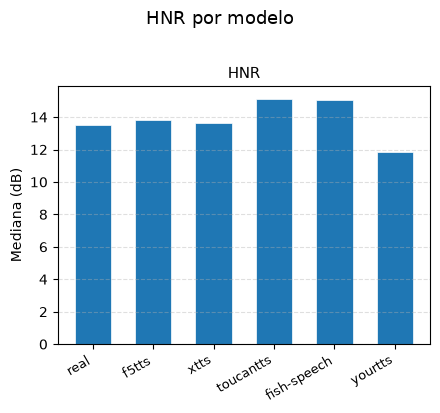

In [24]:
barras_mediana({"HNR": "hnr_mean_dB"}, suptitle="HNR por modelo", ylabel="Mediana (dB)")

## 4. RMS, energia e pausas

In [25]:
def extract_pause_features(row):
    """Extrai features acústicas dos segmentos de pausa (f0 < 0 no REAPER).

    Ressalva: f0 < 0 marca frames *unvoiced* no REAPER, não silêncio puro.
    Consoantes surdas (/s/, /f/, /ʃ/, /p/, /t/, /k/) também caem aqui e têm
    energia real — logo "rms_mean das pausas" mistura silêncio + consoantes
    surdas. Interpretar as conclusões de RMS de pausa com esse cuidado.
    """
    try:
        times = parse_list_col(row["times_reaper"])
        f0    = parse_list_col(row["f0_reaper"])
        y, sr = librosa.load(row["path"], sr=None)

        pause_mask = f0 < 0
        frame_dur  = np.diff(times).mean() if len(times) > 1 else 0.01

        rms_pausas, zcr_pausas, dur_pausas = [], [], []

        def add_segment(t_start, t_end):
            s, e = int(t_start * sr), int(t_end * sr)
            segment = y[s:e]
            if len(segment) > 0:
                rms_pausas.append(np.sqrt(np.mean(segment ** 2)))
                zcr_pausas.append(np.mean(librosa.feature.zero_crossing_rate(segment)[0]))
                dur_pausas.append(t_end - t_start)

        in_pause, t_start = False, None
        for i, is_pause in enumerate(pause_mask):
            if is_pause and not in_pause:
                t_start, in_pause = times[i], True
            elif not is_pause and in_pause:
                add_segment(t_start, times[i - 1] + frame_dur)
                in_pause = False
        if in_pause:                       # pausa que vai até o fim do áudio
            add_segment(t_start, times[-1] + frame_dur)

        return {
            "n_pausas":       len(dur_pausas),
            "rms_mean":       np.mean(rms_pausas) if rms_pausas else np.nan,
            "rms_std":        np.std(rms_pausas)  if rms_pausas else np.nan,
            "zcr_mean":       np.mean(zcr_pausas) if zcr_pausas else np.nan,
            "zcr_std":        np.std(zcr_pausas)  if zcr_pausas else np.nan,
            "pause_dur_mean": np.mean(dur_pausas) if dur_pausas else np.nan,
            "pause_dur_std":  np.std(dur_pausas)  if dur_pausas else np.nan,
        }
    except Exception:
        cols = ["n_pausas", "rms_mean", "rms_std", "zcr_mean",
                "zcr_std", "pause_dur_mean", "pause_dur_std"]
        return {c: np.nan for c in cols}


# Reprocessa: remove colunas antigas e recalcula
pause_cols = ["n_pausas", "rms_mean", "rms_std", "energy_mean", "energy_std",
              "zcr_mean", "zcr_std", "pause_dur_mean", "pause_dur_std"]
data = data.drop(columns=pause_cols, errors="ignore")

rows = [extract_pause_features(row)
        for _, row in tqdm(data.iterrows(), total=len(data),
                           desc="Extraindo features de pausa")]
data = pd.concat([data, pd.DataFrame(rows, index=data.index)], axis=1)

print(f"\nPronto! {len(data)} arquivos processados.")
data[["modelo_grupo", "n_pausas", "rms_mean", "zcr_mean", "pause_dur_mean"]].head(10)

Extraindo features de pausa: 100%|██████████| 7891/7891 [01:14<00:00, 106.56it/s]


Pronto! 7891 arquivos processados.


,modelo_grupo,n_pausas,rms_mean,zcr_mean,pause_dur_mean
0,real,4,0.003958,0.033087,0.227500
1,real,5,0.006822,0.145855,0.263000
2,real,2,0.005641,0.184591,0.070000
3,real,8,0.023282,0.111377,0.141250
4,real,1,0.000469,0.019888,0.550000
5,real,9,0.011764,0.142666,0.140000
6,real,7,0.009372,0.104109,0.292143
7,real,13,0.013024,0.214252,0.198462
8,real,11,0.008359,0.200680,0.245909
9,real,17,0.018226,0.207259,0.160000


In [26]:
PARAMS_PAUSA = {
    "RMS médio das pausas":     "rms_mean",
    "ZCR médio das pausas":     "zcr_mean",
    "Duração média das pausas": "pause_dur_mean",
    "Número de pausas":         "n_pausas",
}
resumo_real_falso(PARAMS_PAUSA)

,real,falso
RMS médio das pausas,0.0105 (0.01086 ± 0.003631),0.01311 (0.01725 ± 0.01134)
ZCR médio das pausas,0.1328 (0.1316 ± 0.0385),0.1376 (0.1365 ± 0.04084)
Duração média das pausas,0.1857 (0.1962 ± 0.07323),0.1689 (0.1796 ± 0.06923)
Número de pausas,22 (22.84 ± 13.55),22 (22.44 ± 13.23)


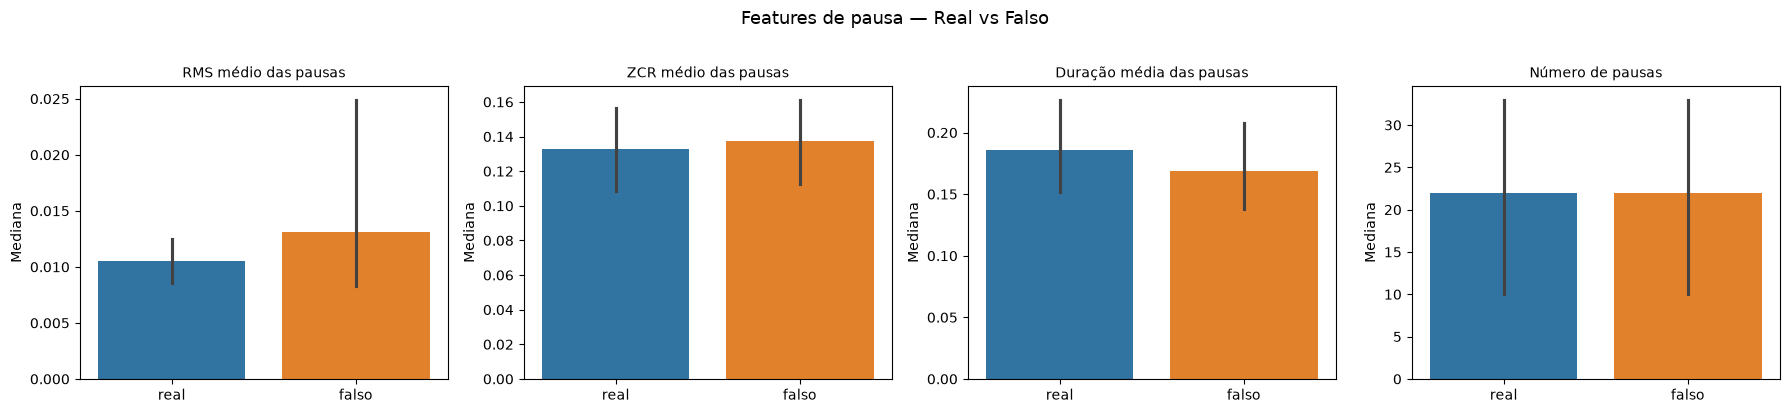

In [27]:
barras_real_falso(PARAMS_PAUSA, suptitle="Features de pausa — Real vs Falso")

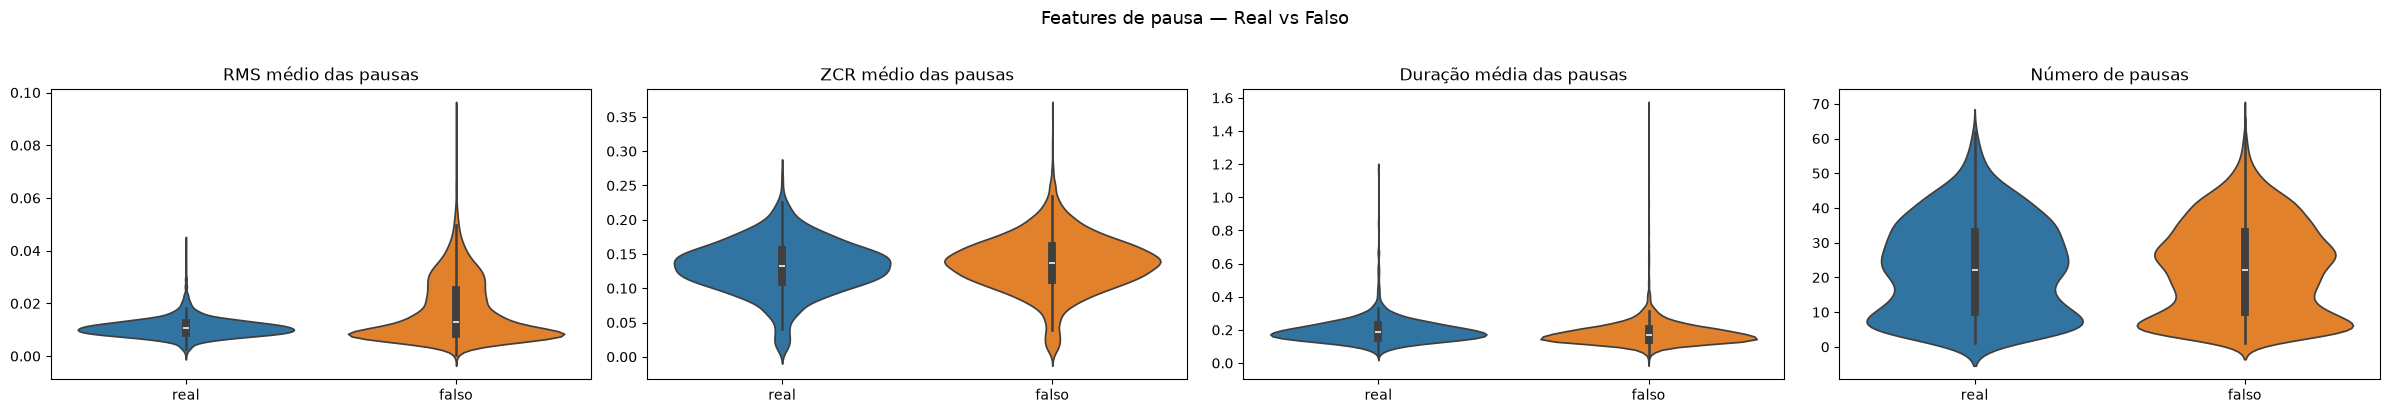

In [28]:
violin_real_falso(PARAMS_PAUSA, suptitle="Features de pausa — Real vs Falso")

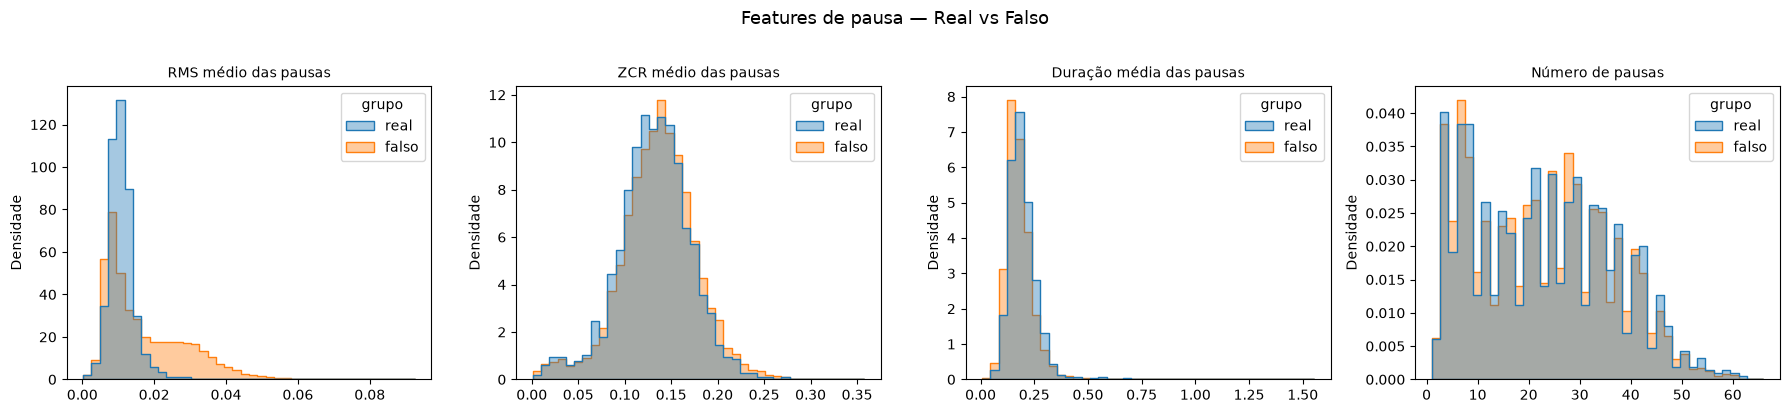

In [29]:
hist_real_falso(PARAMS_PAUSA, suptitle="Features de pausa — Real vs Falso")

### Por modelo

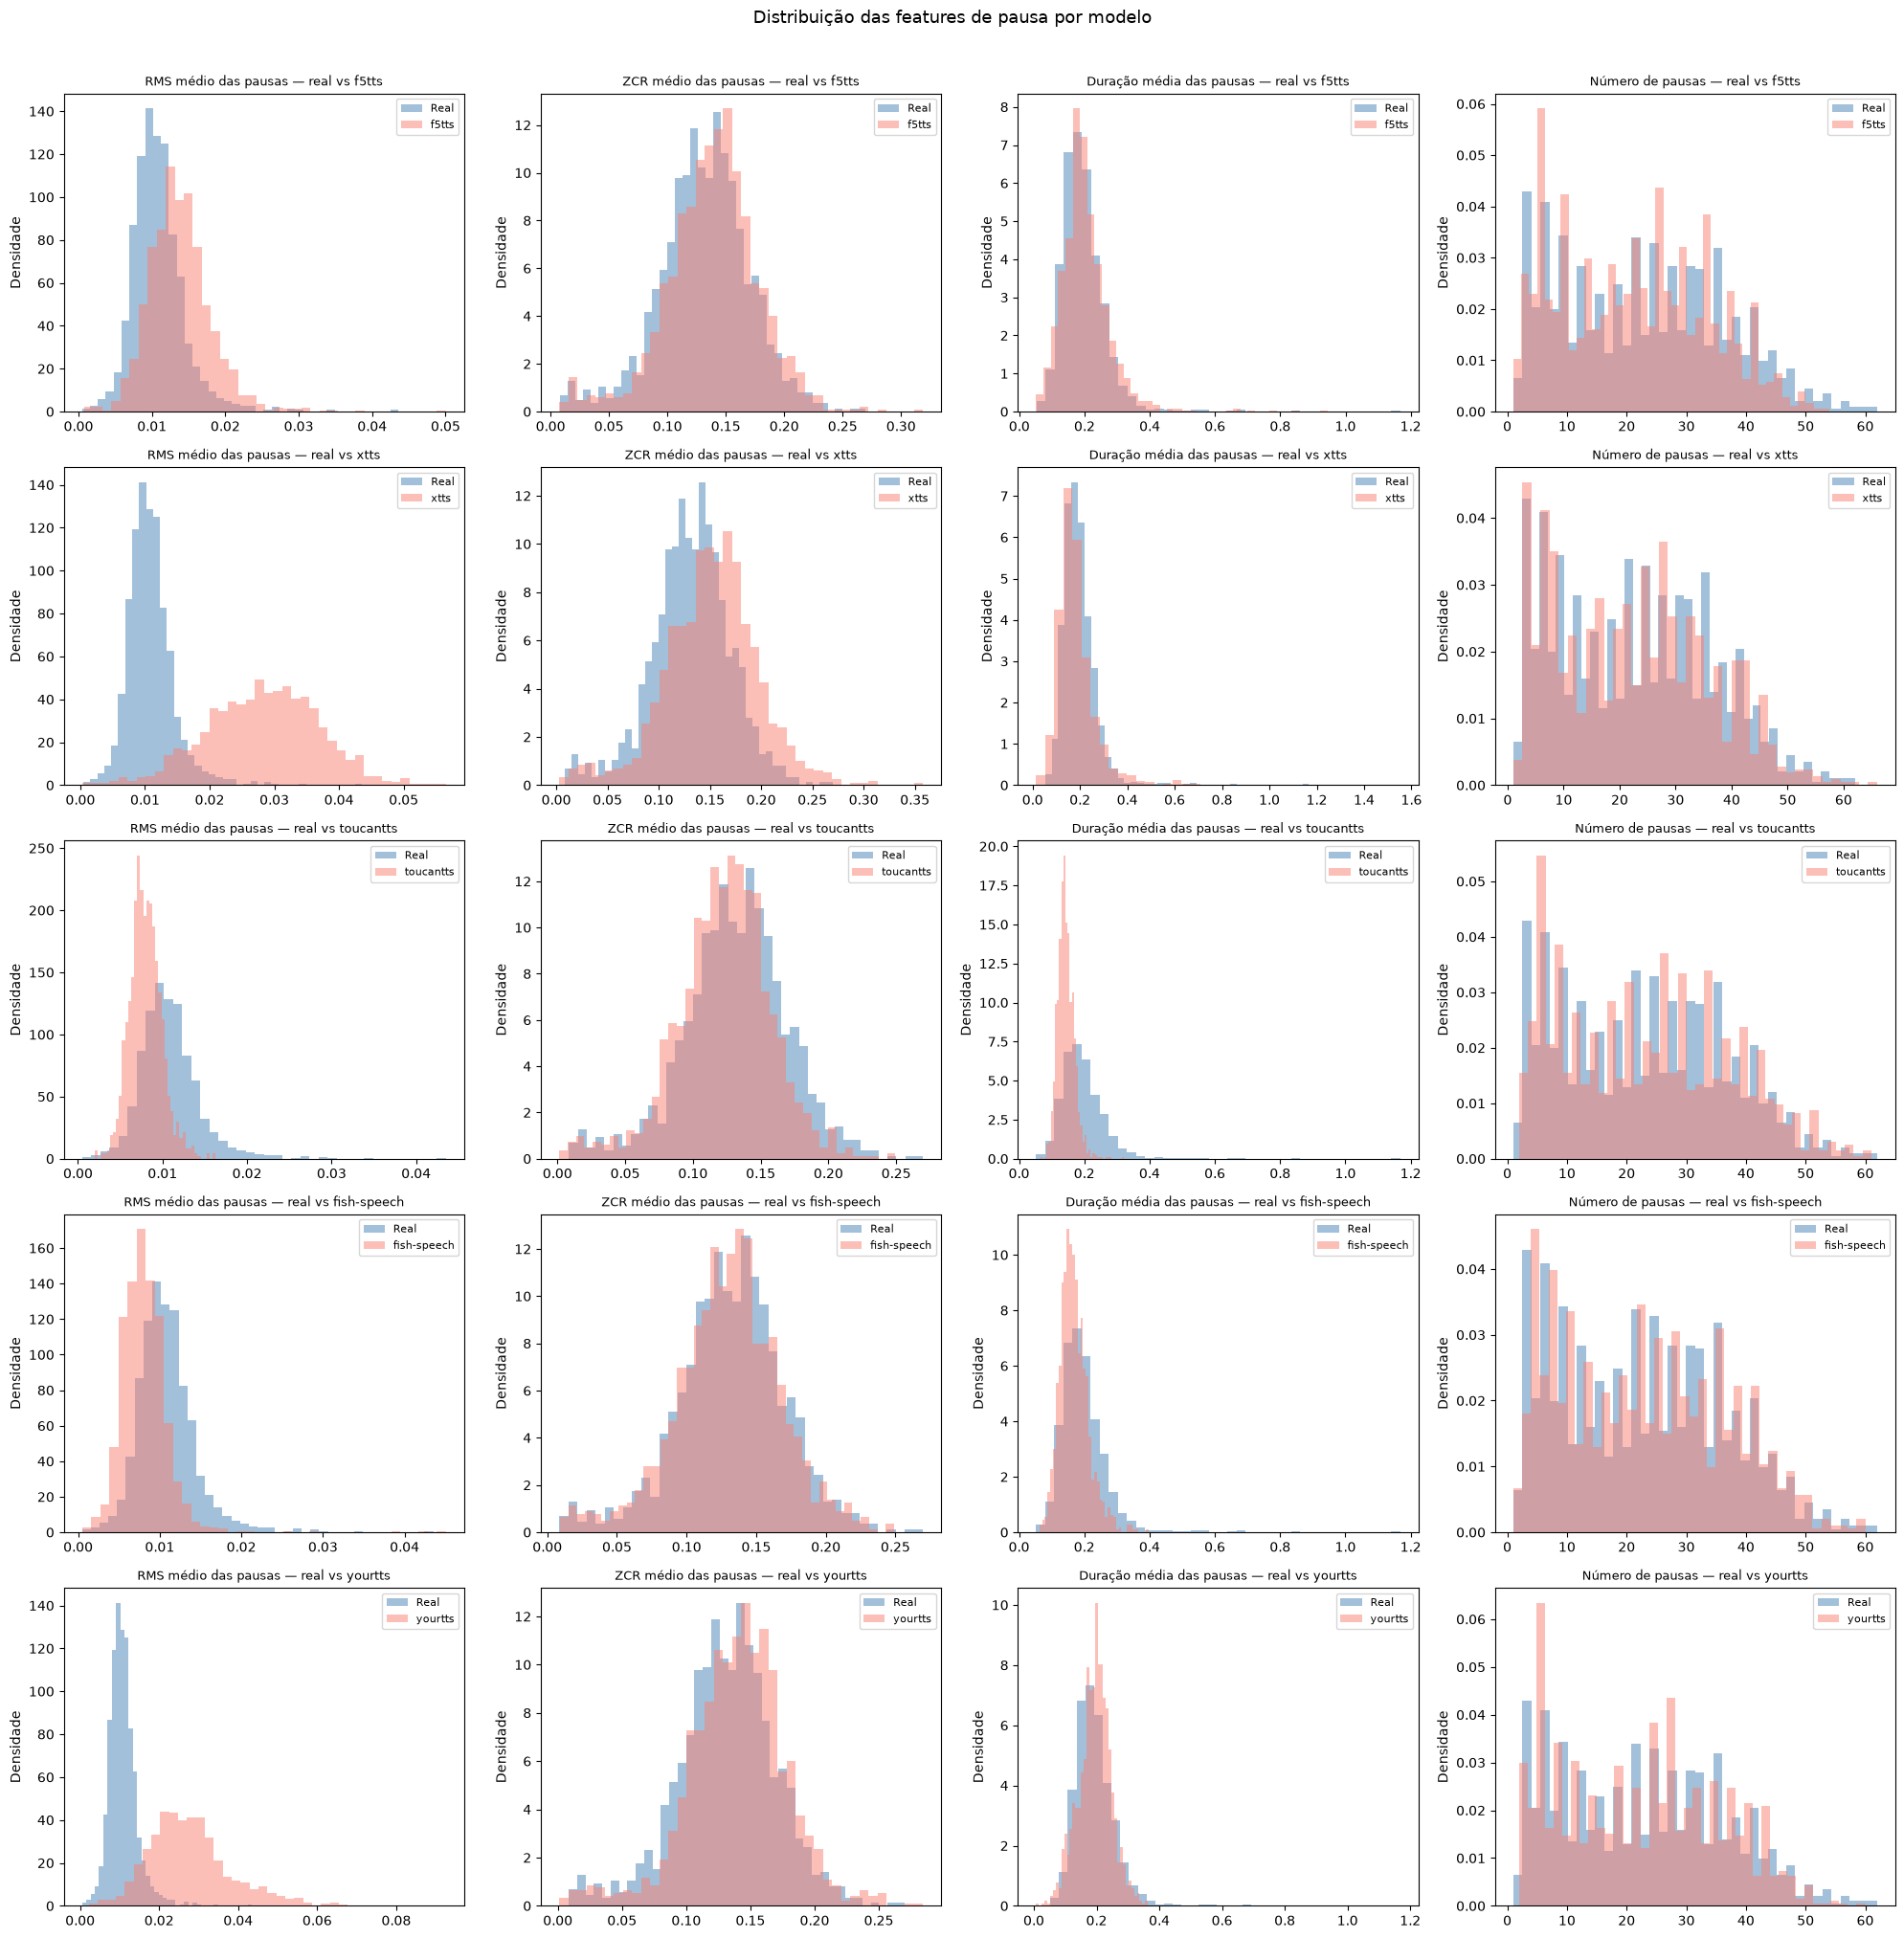

In [30]:
hist_por_modelo(PARAMS_PAUSA, suptitle="Distribuição das features de pausa por modelo")

In [31]:
tabela_kl(PARAMS_PAUSA)

,RMS médio das pausas,ZCR médio das pausas,Duração média das pausas,Número de pausas
Model,,,,
f5tts,0.3336,0.0195,0.0319,0.0330
xtts,2.4829,0.1325,0.0746,0.0024
toucantts,1.4800,0.0457,1.5669,0.0018
fish-speech,0.4870,0.0029,0.3313,0.0006
yourtts,2.2278,0.0302,0.2694,0.0075


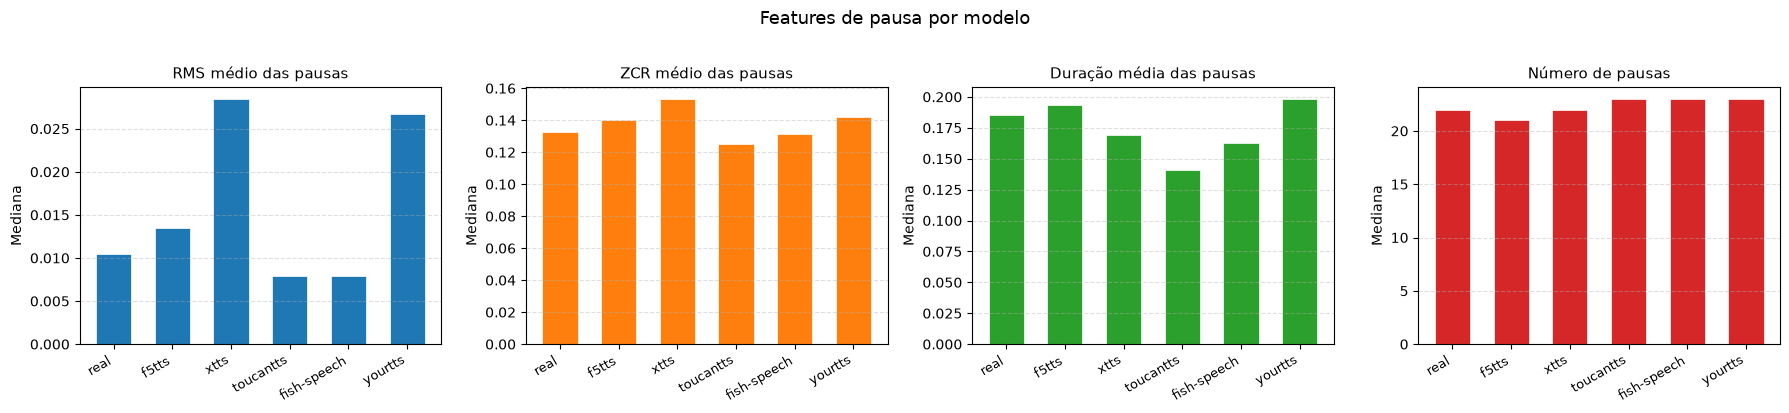

In [32]:
barras_mediana(PARAMS_PAUSA, suptitle="Features de pausa por modelo")

### Observações — Pausas / silêncio

- **A feature mais discriminativa do trabalho é o RMS das pausas.** No agregado, real 0,0105 vs falso 0,0131 — o silêncio sintético **não é realmente silêncio**, carrega energia residual.
  - *Ressalva:* "pausa" aqui = frame *unvoiced* (`f0 < 0` no REAPER), que inclui consoantes surdas (/s/, /f/, /p/...), não só silêncio. Parte da energia residual pode ser consoante, não artefato de TTS. A conclusão provavelmente se mantém, mas a leitura limpa exigiria isolar silêncio real (limiar de RMS ou VAD).
- **Por modelo (KL):**
  - **XTTS (KL 2,48)** e **YourTTS (KL 2,23)** vazam muita energia nas pausas — artefato fortíssimo, provavelmente o melhor sinal isolado para detecção. **Crítico no caso do XTTS:** ele tem **o melhor WER de todos (5,50%, abaixo do bona fide 9,11) e SI-SDR altíssimo**, ou seja, soa ótimo e é hiperinteligível — mas se denuncia justamente no silêncio.
  - **ToucanTTS** tem problema na **duração das pausas (KL 1,57)** — timing/ritmo artificial, consistente com o problema de F0-std e com seu **pior WER (19,18%)**.
- **Duração das pausas:** real ligeiramente mais longa (0,186 vs 0,169 s).
- **Número de pausas é inútil para discriminar:** mediana idêntica (22 vs 22) e KL ~0 para todos. Pode ser descartada.
- **ZCR das pausas** também pouco informativo.

# Resumo

| Modelo | uTMOS↑ | Spk.Sim↑ | SI-SDR↑ | WER↓ | Fidelidade acústica (KL) | Artefato dominante |
|---|---|---|---|---|---|---|
| Fish-Speech | 3,11 | **0,76** | 22,33 | 11,43 | **Melhor** | HNR alto (limpo demais) |
| XTTS | 3,37 | 0,71 | 25,97 | **5,50** | Boa | RMS de pausa (2,48) + limpo demais |
| F5-TTS | **3,39** | 0,71 | 20,86 | 14,13 | Boa | Shimmer (1,11) |
| ToucanTTS | 3,20 | 0,60 | **26,50** | 19,18 | Fraca | F0-std + duração de pausa (prosódia) |
| YourTTS | 2,58 | 0,41 | 16,92 | 14,21 | **Pior** | HNR baixo, RMS pausa, shimmer (tudo) |
| *Bona fide* | 3,44 | – | – | 9,11 | (referência) | — |




- **Spk. Sim. valida o ranking de KL de forma independente.** Os extremos coincidem: Fish-Speech tem a maior Spk. Sim. (0,76) **e** os menores KLs; YourTTS tem a menor (0,41) **e** os maiores. Clonar a *identidade* da voz exige acertar F0/jitter/shimmer/HNR — exatamente o que o KL mede. Duas evidências convergentes para a mesma ordenação.
- **O eixo "limpo demais": HNR ↔ SI-SDR.** Modelos com sinal sintético muito limpo aparecem com HNR alto (acústica) e SI-SDR alto (tabela) — ToucanTTS e Fish-Speech. Isso é "bom" para qualidade, mas é um **sinal de detecção**: fala real tem ruído e coarticulação que esses modelos suprimem.
- **ToucanTTS — paradoxo sinal-limpo / prosódia-quebrada:** melhor SI-SDR (26,50) mas pior WER (19,18%) e os piores KLs de F0-std (1,95) e duração de pausa (1,57). Reconstrói a forma de onda de modo limpo, mas erra prosódia e ritmo. SI-SDR não pune isso (mede distorção de sinal, não linguística) — as features de F0 e pausa capturam o que a tabela esconde.
- **uTMOS confirma "natural ≠ fiel":** Fish-Speech é o mais fiel (acústica + Spk. Sim. 0,76), mas tem o pior uTMOS entre os bons modelos (3,11). Reproduzir fielmente o locutor — inclusive imperfeições — não maximiza a naturalidade percebida. F5-TTS/XTTS lideram o uTMOS (3,39/3,37, perto do real 3,44) sem serem os mais fiéis.
- **YourTTS é coerente em tudo:** pior uTMOS (2,58), pior Spk. Sim. (0,41), pior SI-SDR (16,92) e piores KLs. Único modelo "ruim em todos os eixos" — o mais fácil de detectar.

## 5.1. Síntese e conclusões

- **Estatísticas agregadas enganam.** Medianas real vs "falso" são quase iguais em quase tudo; o poder discriminativo está **por modelo** e em **features específicas**, não na média global.
- **Dois eixos distintos, que não apontam o mesmo "melhor modelo":** (1) *qualidade percebida* (uTMOS, SI-SDR, WER) e (2) *fidelidade/detectabilidade* (Spk. Sim., HNR, F0-std, RMS de pausa).
- **Ranking de fidelidade acústica (menor KL):** Fish-Speech (mais próximo do real) → XTTS/F5-TTS → ToucanTTS → YourTTS (mais distante) — corroborado pela Spk. Sim. da tabela.
- **Proximidade acústica ≠ naturalidade percebida:** Fish-Speech é o mais "colado" nas métricas mas tem uTMOS baixo; F5-TTS/XTTS soam mais naturais apesar de artefatos pontuais.
- **Qualidade alta é contraproducente para o disfarce:** XTTS e ToucanTTS já superam o real em WER/SI-SDR, e essa "perfeição" os denuncia. A detecção **não** deve se apoiar em qualidade global, e sim em artefatos residuais — sobretudo **RMS das pausas** e **HNR/limpeza excessiva**, que persistem mesmo nos modelos de ponta.
- **Features mais promissoras para detecção, em ordem:** (1) RMS das pausas, (2) HNR por modelo, (3) desvio de F0, (4) shimmer. **Descartáveis:** número de pausas e, em parte, F0 média.
- **YourTTS é o mais fácil de detectar** (ruim em todos os eixos, acústicos e de qualidade); **Fish-Speech/XTTS são os mais difíceis.**

## 5.2. Ressalvas metodológicas

- **KL é assimétrica e sensível à binagem** — use como *ranking relativo*, não valor absoluto; idealmente reportar a direção (modelo→real ou real→modelo) usada.
- **Desbalanceamento 83/17** exige cuidado se houver classificação (F1/AUC em vez de acurácia, balanceamento ou reponderação).
- **Só o split `test`** foi analisado — convém confirmar se a intenção era essa.
- **"Pausa" = *unvoiced*, não silêncio.** Os segmentos vêm de `f0 < 0` (REAPER), que também marca consoantes surdas. As features de pausa — sobretudo `rms_mean`, apontada como a mais discriminativa — devem ser lidas com essa ressalva; idealmente filtrar por energia baixa para isolar silêncio de fato.
- **Robustez:** complementar as comparações de distribuição com teste estatístico (ex.: Mann-Whitney por feature) e *effect size* (Cliff's delta), já que o n é grande e diferenças pequenas tendem a sair "significativas".